In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#df = pd.read_csv('/Users/aysylu/Downloads/sales_data_sample.csv', encoding='ISO-8859-1')
#df.head()

In [3]:
df = pd.read_csv('/Users/aysylu/sales_data.csv', encoding='ISO-8859-1')
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   str    
 6   STATUS            2823 non-null   str    
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   str    
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   str    
 13  CUSTOMERNAME      2823 non-null   str    
 14  PHONE             2823 non-null   str    
 15  ADDRESSLINE1      2823 non-null   str    
 16  ADDRESSLINE2      302 non-null    str    
 17  CITY  

In [5]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [6]:
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [7]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])
df.set_index('ORDERDATE', inplace=True)
df['year'] = df.index.year
df['month'] = df.index.month

In [8]:
monthly = df.resample('ME')['SALES'].sum()
monthly.head(12)

ORDERDATE
2003-01-31     129753.60
2003-02-28     140836.19
2003-03-31     174504.90
2003-04-30     201609.55
2003-05-31     192673.11
2003-06-30     168082.56
2003-07-31     187731.88
2003-08-31     197809.30
2003-09-30     263973.36
2003-10-31     568290.97
2003-11-30    1029837.66
2003-12-31     261876.46
Freq: ME, Name: SALES, dtype: float64

In [9]:
monthly = df.resample('ME')['SALES'].sum()
monthly

ORDERDATE
2003-01-31     129753.60
2003-02-28     140836.19
2003-03-31     174504.90
2003-04-30     201609.55
2003-05-31     192673.11
2003-06-30     168082.56
2003-07-31     187731.88
2003-08-31     197809.30
2003-09-30     263973.36
2003-10-31     568290.97
2003-11-30    1029837.66
2003-12-31     261876.46
2004-01-31     316577.42
2004-02-29     311419.53
2004-03-31     205733.73
2004-04-30     206148.12
2004-05-31     273438.39
2004-06-30     286674.22
2004-07-31     327144.09
2004-08-31     461501.27
2004-09-30     320750.91
2004-10-31     552924.25
2004-11-30    1089048.01
2004-12-31     372802.66
2005-01-31     339543.42
2005-02-28     358186.18
2005-03-31     374262.76
2005-04-30     261633.29
2005-05-31     457861.06
Freq: ME, Name: SALES, dtype: float64

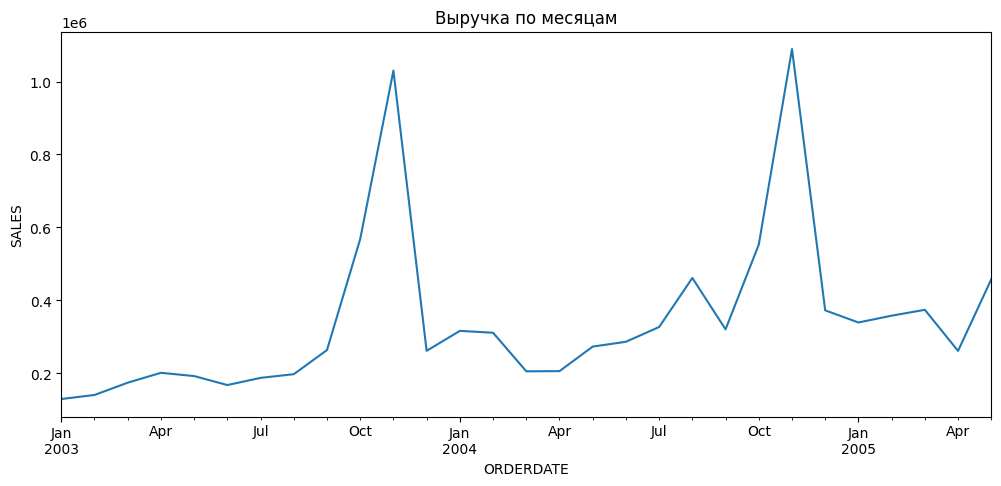

In [10]:
import matplotlib.pyplot as plt

monthly.plot(figsize=(12, 5), title='Выручка по месяцам')
plt.ylabel('SALES')
plt.show()

In [11]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,...,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,year,month
ORDERDATE,,,,,,,,,,,,,,,,,,,,,
2003-02-24,10107,30,95.70,2,2871.00,Shipped,1,2,2003,Motorcycles,...,NYC,NY,10022,USA,NaN,Yu,Kwai,Small,2003,2
2003-05-07,10121,34,81.35,5,2765.90,Shipped,2,5,2003,Motorcycles,...,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small,2003,5
2003-07-01,10134,41,94.74,2,3884.34,Shipped,3,7,2003,Motorcycles,...,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium,2003,7
2003-08-25,10145,45,83.26,6,3746.70,Shipped,3,8,2003,Motorcycles,...,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium,2003,8
2003-10-10,10159,49,100.00,14,5205.27,Shipped,4,10,2003,Motorcycles,...,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium,2003,10


In [12]:
type(monthly)

pandas.Series

In [13]:
monthly

ORDERDATE
2003-01-31     129753.60
2003-02-28     140836.19
2003-03-31     174504.90
2003-04-30     201609.55
2003-05-31     192673.11
2003-06-30     168082.56
2003-07-31     187731.88
2003-08-31     197809.30
2003-09-30     263973.36
2003-10-31     568290.97
2003-11-30    1029837.66
2003-12-31     261876.46
2004-01-31     316577.42
2004-02-29     311419.53
2004-03-31     205733.73
2004-04-30     206148.12
2004-05-31     273438.39
2004-06-30     286674.22
2004-07-31     327144.09
2004-08-31     461501.27
2004-09-30     320750.91
2004-10-31     552924.25
2004-11-30    1089048.01
2004-12-31     372802.66
2005-01-31     339543.42
2005-02-28     358186.18
2005-03-31     374262.76
2005-04-30     261633.29
2005-05-31     457861.06
Freq: ME, Name: SALES, dtype: float64

In [14]:
monthly_df = monthly.reset_index()
monthly_df.head(10)

,ORDERDATE,SALES
0,2003-01-31,129753.60
1,2003-02-28,140836.19
2,2003-03-31,174504.90
3,2003-04-30,201609.55
4,2003-05-31,192673.11
5,2003-06-30,168082.56
6,2003-07-31,187731.88
7,2003-08-31,197809.30
8,2003-09-30,263973.36
9,2003-10-31,568290.97


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df[df.duplicated()]

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,...,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,year,month
ORDERDATE,,,,,,,,,,,,,,,,,,,,,


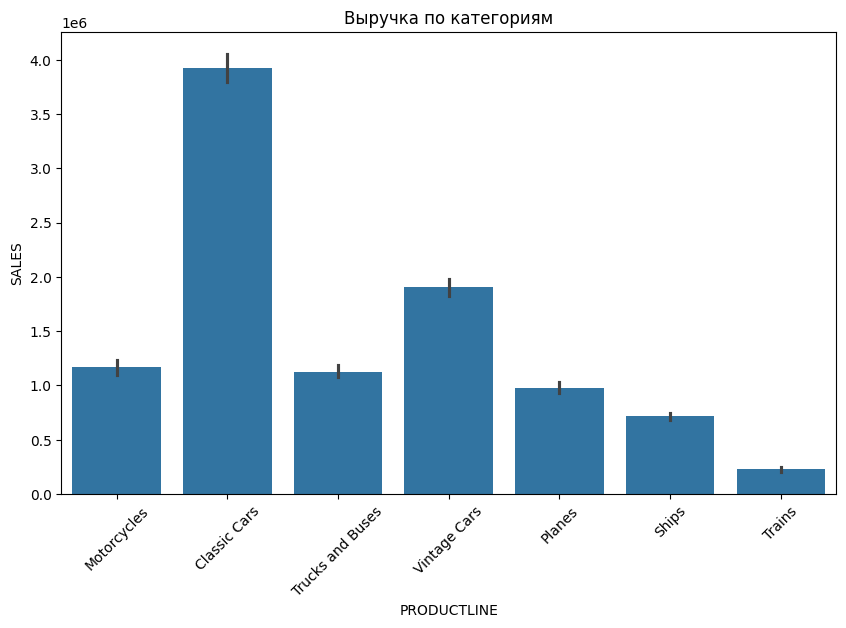

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='PRODUCTLINE', y='SALES', estimator=sum)
plt.xticks(rotation=45)
plt.title('Выручка по категориям')
plt.show()

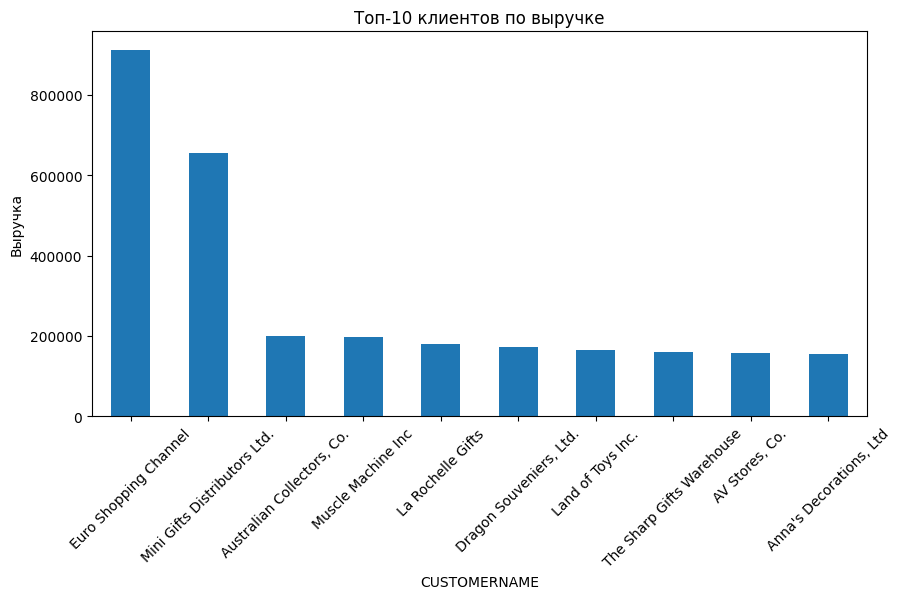

In [19]:
top_customers = df.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
top_customers.plot(kind='bar')
plt.title('Топ-10 клиентов по выручке')
plt.xticks(rotation=45)
plt.ylabel('Выручка')
plt.show()